In [1]:
import sys, json, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25})
BAD, GOOD, NEUTRAL, ACCENT = "#c0392b", "#1e8449", "#7f8c8d", "#2c6fbb"
RES = "../data/results/"


# P6 - Segment p-hacking

## 1. What goes wrong
The test did not win overall, so you slice by device, city and tier until a segment does. Slicing afterwards almost guarantees a significant slice.

## 2. Simulate

In [2]:
from abtest.pitfalls import segments
seg = pd.DataFrame([segments.segment_hacking(n_segments=m, n_sims=20_000) for m in (1, 3, 5, 10, 15, 30)])
seg.round(3)

,n_segments,any_segment_significant,avg_reported_abs_lift_in_winner,bonferroni_any_significant,followup_confirms
0,1,0.049,0.087,0.049,0.051
1,3,0.144,0.151,0.051,0.056
2,5,0.230,0.196,0.050,0.048
3,10,0.407,0.282,0.050,0.051
4,15,0.536,0.355,0.048,0.047
5,30,0.785,0.537,0.046,0.050


## 3. Quantify the damage

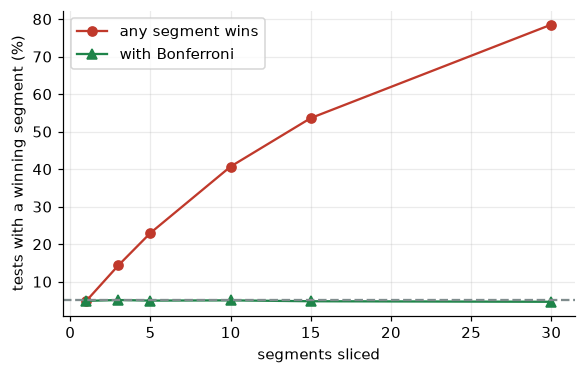

In [3]:
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(seg.n_segments, seg.any_segment_significant * 100, 'o-', color=BAD, label='any segment wins'); ax.plot(seg.n_segments, seg.bonferroni_any_significant * 100, '^-', color=GOOD, label='with Bonferroni'); ax.axhline(5, color=NEUTRAL, ls='--'); ax.legend(); ax.set(xlabel='segments sliced', ylabel='tests with a winning segment (%)'); plt.show()

## 4. Detect

Compare the list of segments analysed against the list committed to before launch. Anything analysed after the fact is exploratory.

## 5. Fix

Pre-register segments, correct for the number you test, and treat post-hoc segment findings as **hypotheses for a new test**, not reasons to ship.

## 6. Verify the fix

In [4]:
r = segments.segment_hacking(n_segments=15, n_sims=20_000)
print(f"15 segments: {r['any_segment_significant']:.1%} of no-effect tests have a 'winner' (avg reported lift {r['avg_reported_abs_lift_in_winner']:.0%}); a follow-up confirms it {r['followup_confirms']:.1%} of the time")

15 segments: 53.6% of no-effect tests have a 'winner' (avg reported lift 35%); a follow-up confirms it 4.7% of the time


## So what
A 'winning' segment in a no-effect test is the norm, not the exception, and it shows a large, convincing lift. Follow-up tests almost never confirm it.